<a href="https://colab.research.google.com/github/Adnaan-khan/Practice-projects/blob/main/ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler

In [ ]:
X,y = load_iris(return_X_y=True)
X = StandardScaler().fit_transform(X)
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=.2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Accuracy: 0.8999999761581421


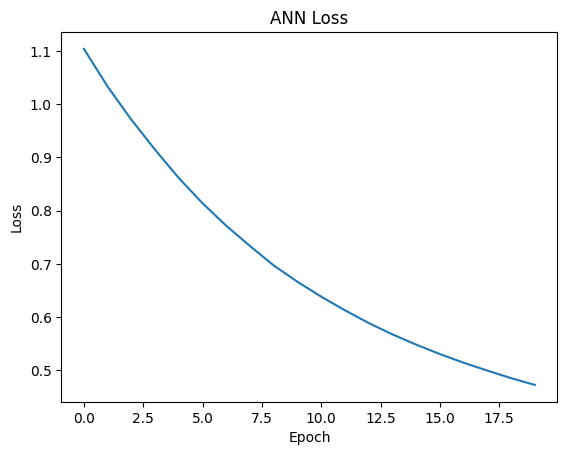

In [ ]:
#ANN Model to take positive values the use exponential of this value to normalize data
import matplotlib.pyplot as plt
model = Sequential([
    Dense(64,activation = 'relu'),
    Dense(3,activation = 'softmax'),
])
model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])
history = model.fit(X_train,y_train,epochs = 20 ,verbose =0)

y_pred = model.predict(X_test).argmax(axis = 1)

loss,acc = model.evaluate(X_test,y_test, verbose = 0)
print("Accuracy:",acc)

plt.plot(history.history['loss'])
plt.title('ANN Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()
#


In [ ]:
#confusion matrix and comparing actual and predicted test categories


   Actual  Predicted
0       1          2
1       2          2
2       2          2
3       0          0
4       0          0


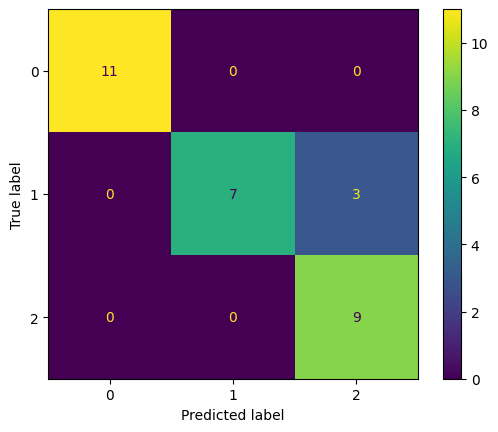

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay

df = pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred,
})
print(df.head(5))

# confusion matrix
cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()